# Análise de Dados: AnáliseExploratória de Dados de Logística I

## Projeto

### Análise exploratória de dados através das seguintes etapas:
**1. Exploração;**

**2. Manipulação;**

**3. Visualização;**

**4. Storytelling.**

# 1. Exploração

## 1.1 Importando Biblíotecas e Dados

In [47]:
import pandas as pd
import json
import geopy
import geopandas
import numpy as np
import warnings
import streamlit as st
import folium
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter


with open(r'C:\Users\luiz_\Documents\Projetos_Analista_de_Dados\Projeto_Transporte\projeto_transporte\dados\deliveries.json', encoding='utf8') as file:
    data = json.load(file)

In [48]:
#Verificando quantas instâncias compões os nossos dados.

len(data)

199

In [49]:
#Criando variável.
example = data[0]

#Imprimindo as series dos nossos dados.
print(example.keys())

dict_keys(['name', 'region', 'origin', 'vehicle_capacity', 'deliveries'])


In [50]:
example['name']

'cvrp-2-df-33'

In [51]:
example['region']

'df-2'

In [52]:
example['origin']['lat']

-15.83814451122274

In [53]:
example['origin']['lng']

-48.05498915846707

In [54]:
example['vehicle_capacity']

180

In [55]:
example['deliveries'][0]['point']['lat']

-15.848929154862294

## 1.2 Manipulação dos Dados - Wranglig

In [12]:
df_deliveries = pd.DataFrame(data)

In [13]:
df_deliveries.head()

,name,region,origin,vehicle_capacity,deliveries
0,cvrp-2-df-33,df-2,"{'lng': -48.05498915846707, 'lat': -15.8381445...",180,"[{'id': '313483a19d2f8d65cd5024c8d215cfbd', 'p..."
1,cvrp-2-df-73,df-2,"{'lng': -48.05498915846707, 'lat': -15.8381445...",180,"[{'id': 'bf3fc630b1c29601a4caf1bdd474b85', 'po..."
2,cvrp-2-df-20,df-2,"{'lng': -48.05498915846707, 'lat': -15.8381445...",180,"[{'id': 'b30f1145a2ba4e0b9ac0162b68d045c3', 'p..."
3,cvrp-1-df-71,df-1,"{'lng': -47.89366206897872, 'lat': -15.8051175...",180,"[{'id': 'be3ed547394196c12c7c27c89ac74ed6', 'p..."
4,cvrp-2-df-87,df-2,"{'lng': -48.05498915846707, 'lat': -15.8381445...",180,"[{'id': 'a6328fb4dc0654eb28a996a270b0f6e4', 'p..."


**Coluna**: origin

A coluna origin contem dados ***nested*** ou aninhados na estrutura do JSON.
Vou precisar normalizar a coluna com uma operação conhecida como ***flatten*** ou ***achatamento*** que transforma cada chave do JSON em uma nova coluna:

In [14]:
hub_origin_df = pd.json_normalize(df_deliveries['origin'])
hub_origin_df.head()

,lng,lat
0,-48.054989,-15.838145
1,-48.054989,-15.838145
2,-48.054989,-15.838145
3,-47.893662,-15.805118
4,-48.054989,-15.838145


Agora com os dados achatados, preciso junta-los ao conjunto de dados principal:

In [15]:
df_deliveries = pd.merge(left=df_deliveries, right=hub_origin_df,
                         how='inner', left_index=True, right_index=True)
df_deliveries.head()

,name,region,origin,vehicle_capacity,deliveries,lng,lat
0,cvrp-2-df-33,df-2,"{'lng': -48.05498915846707, 'lat': -15.8381445...",180,"[{'id': '313483a19d2f8d65cd5024c8d215cfbd', 'p...",-48.054989,-15.838145
1,cvrp-2-df-73,df-2,"{'lng': -48.05498915846707, 'lat': -15.8381445...",180,"[{'id': 'bf3fc630b1c29601a4caf1bdd474b85', 'po...",-48.054989,-15.838145
2,cvrp-2-df-20,df-2,"{'lng': -48.05498915846707, 'lat': -15.8381445...",180,"[{'id': 'b30f1145a2ba4e0b9ac0162b68d045c3', 'p...",-48.054989,-15.838145
3,cvrp-1-df-71,df-1,"{'lng': -47.89366206897872, 'lat': -15.8051175...",180,"[{'id': 'be3ed547394196c12c7c27c89ac74ed6', 'p...",-47.893662,-15.805118
4,cvrp-2-df-87,df-2,"{'lng': -48.05498915846707, 'lat': -15.8381445...",180,"[{'id': 'a6328fb4dc0654eb28a996a270b0f6e4', 'p...",-48.054989,-15.838145


In [16]:
# Eliminando a coluna origin.
df_deliveries = df_deliveries.drop('origin', axis=1)

# Reordenando as colunas após achatamento da coluna origin.
df_deliveries = df_deliveries[['name', 'region', 'lng', 'lat', 'vehicle_capacity', 'deliveries']]

# Dando um novo nome para as novas colunas lat e lng derivadas do achatamento da coluna origin.
df_deliveries.rename(columns={'lng': 'hub_lng', 'lat': 'hub_lat'}, inplace=True)

In [17]:
df_deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              199 non-null    object 
 1   region            199 non-null    object 
 2   hub_lng           199 non-null    float64
 3   hub_lat           199 non-null    float64
 4   vehicle_capacity  199 non-null    int64  
 5   deliveries        199 non-null    object 
dtypes: float64(2), int64(1), object(3)
memory usage: 9.5+ KB


**Coluna**: deliveries

Repare que a coluna deliveries contem uma lista de dados ***nested*** ou ***aninhados***
na estrutura do JSON.
Vou precisar normalizar a coluna com uma operação conhecida como
***explode*** ou ***explosão*** que transforma cada elemento da lista em uma linha.
Por fim, farei o flatten ou achatamento do resultado coluna:

In [18]:
# Explodindo os dados com a função explode.

df_deliveries_exploded = df_deliveries[['deliveries']].explode('deliveries')
df_deliveries_exploded.head()

,deliveries
0,"{'id': '313483a19d2f8d65cd5024c8d215cfbd', 'po..."
0,"{'id': '320c94b17aa685c939b3f3244c3099de', 'po..."
0,"{'id': '3663b42f4b8decb33059febaba46d5c8', 'po..."
0,"{'id': 'e11ab58363c38d6abc90d5fba87b7d7', 'poi..."
0,"{'id': '54cb45b7bbbd4e34e7150900f92d7f4b', 'po..."


In [19]:
#Normalizando os dados e renomeando as colunas geradas pelo achatamento da coluna deliveries
df_deliveries_normalized = pd.concat([
    pd.DataFrame(df_deliveries_exploded['deliveries'].apply(lambda record: record['size'])).rename(columns={'deliveries': 'delivery_size'}),
    pd.DataFrame(df_deliveries_exploded['deliveries'].apply(lambda record: record['point']['lng'])).rename(columns={'deliveries': 'delivery_lng'}),
    pd.DataFrame(df_deliveries_exploded['deliveries'].apply(lambda record: record['point']['lat'])).rename(columns={'deliveries': 'delivery_lat'}),
], axis=1)

df_deliveries_normalized.tail()

,delivery_size,delivery_lng,delivery_lat
198,8,-48.064269,-15.997694
198,4,-48.065176,-16.003597
198,9,-48.065841,-16.003808
198,1,-48.062327,-16.001568
198,9,-48.059420,-16.009234


In [20]:
len(df_deliveries_normalized)

636149

In [21]:
len(df_deliveries)

199

In [22]:
# Eliminando a coluna deliveries.
df_deliveries = df_deliveries.drop('deliveries', axis=1)

# Juntando as novas colunas ao dataframe original
df_deliveries = pd.merge(left=df_deliveries, right=df_deliveries_normalized, how='right', left_index=True, right_index=True)
df_deliveries.reset_index(inplace=True, drop=True)

df_deliveries.tail()

,name,region,hub_lng,hub_lat,vehicle_capacity,delivery_size,delivery_lng,delivery_lat
636144,cvrp-2-df-62,df-2,-48.054989,-15.838145,180,8,-48.064269,-15.997694
636145,cvrp-2-df-62,df-2,-48.054989,-15.838145,180,4,-48.065176,-16.003597
636146,cvrp-2-df-62,df-2,-48.054989,-15.838145,180,9,-48.065841,-16.003808
636147,cvrp-2-df-62,df-2,-48.054989,-15.838145,180,1,-48.062327,-16.001568
636148,cvrp-2-df-62,df-2,-48.054989,-15.838145,180,9,-48.059420,-16.009234


### Melhoria para enriquecimento do prodjeto.

Iniciamente vou separar os dados dos Hubs para fazer a ***geocodificação reversa***, após isso vou fazer o mesmo processo para dos dados de entregas.

In [23]:
df_hub = df_deliveries[['region',  'hub_lng', 'hub_lat']]
df_hub = df_hub.drop_duplicates().sort_values(by='region').reset_index(drop=True)

# Criação de variavel para criação do mapa
df_hub_coordinates = df_hub.copy()

df_hub.head()

,region,hub_lng,hub_lat
0,df-0,-47.802665,-15.657014
1,df-1,-47.893662,-15.805118
2,df-2,-48.054989,-15.838145


In [24]:
geolocator = Nominatim(user_agent='ebac_geocoder')
location = geolocator.reverse('-15.657013854445248, -47.802664728268745')

print(json.dumps(location.raw, indent=2, ensure_ascii=False))

{
  "place_id": 14400541,
  "licence": "Data © OpenStreetMap contributors, ODbL 1.0. http://osm.org/copyright",
  "osm_type": "way",
  "osm_id": 240210480,
  "lat": "-15.6569160",
  "lon": "-47.8026446",
  "class": "highway",
  "type": "secondary",
  "place_rank": 26,
  "importance": 0.053411383993285995,
  "addresstype": "road",
  "name": "Rua 7",
  "display_name": "Rua 7, Quadra 2, Vila DNOCS, Sobradinho, Região Geográfica Imediata do Distrito Federal, Região Integrada de Desenvolvimento do Distrito Federal e Entorno, Região Geográfica Intermediária do Distrito Federal, Distrito Federal, Região Centro-Oeste, 73015-202, Brasil",
  "address": {
    "road": "Rua 7",
    "residential": "Quadra 2",
    "suburb": "Vila DNOCS",
    "town": "Sobradinho",
    "municipality": "Região Geográfica Imediata do Distrito Federal",
    "county": "Região Integrada de Desenvolvimento do Distrito Federal e Entorno",
    "state_district": "Região Geográfica Intermediária do Distrito Federal",
    "state"

In [25]:
# O serviço de geocodificação reversa é limitado ao tempo de codificação de 1 em 1 segundo por linhas,
# esse código garante que seja feita as consultas respentando esse parâmetro.

gecoder = RateLimiter(geolocator.reverse, min_delay_seconds=1)

In [26]:
df_hub['coordinates'] = df_hub['hub_lat'].astype(str) + ',' + df_hub['hub_lng'].astype(str)
df_hub['geodata'] = df_hub['coordinates'].apply(gecoder)

df_hub.head()

,region,hub_lng,hub_lat,coordinates,geodata
0,df-0,-47.802665,-15.657014,"-15.657013854445248,-47.802664728268745","(Rua 7, Quadra 2, Vila DNOCS, Sobradinho, Regi..."
1,df-1,-47.893662,-15.805118,"-15.80511751066334,-47.89366206897872","(SQS 303, Asa Sul, Brasília, Plano Piloto, Reg..."
2,df-2,-48.054989,-15.838145,"-15.83814451122274,-48.05498915846707","(Armazém do Bolo, lote 4/8, CSB 4/5, Setor B S..."


In [27]:
df_hub_geodata = pd.json_normalize(df_hub['geodata'].apply(lambda data: data.raw))

df_hub_geodata.head()

,place_id,licence,osm_type,osm_id,lat,lon,class,type,place_rank,importance,...,address.ISO3166-2-lvl4,address.region,address.postcode,address.country,address.country_code,address.neighbourhood,address.city,address.shop,address.house_number,address.quarter
0,14400541,"Data © OpenStreetMap contributors, ODbL 1.0. h...",way,240210480,-15.6569160,-47.8026446,highway,secondary,26,0.053411,...,BR-DF,Região Centro-Oeste,73015-202,Brasil,br,NaN,NaN,NaN,NaN,NaN
1,14862909,"Data © OpenStreetMap contributors, ODbL 1.0. h...",way,66353368,-15.8051728,-47.8937235,highway,residential,26,0.053411,...,BR-DF,Região Centro-Oeste,70336-000,Brasil,br,SQS 303,Brasília,NaN,NaN,NaN
2,11687316,"Data © OpenStreetMap contributors, ODbL 1.0. h...",node,6249717596,-15.8384371,-48.0552917,shop,pastry,30,0.000051,...,BR-DF,Região Centro-Oeste,72015-030,Brasil,br,NaN,Taguatinga,Armazém do Bolo,lote 4/8,Setor B Sul


In [28]:
df_hub_geodata = df_hub_geodata[['address.town', 'address.suburb', 'address.city']]
df_hub_geodata.rename(columns={'address.town': 'hub_town','address.suburb': 'hub_suburb','address.city': 'hub_city'}, inplace=True)
df_hub_geodata['hub_city'] = np.where(df_hub_geodata['hub_city'].notna(),df_hub_geodata['hub_city'],df_hub_geodata['hub_town'])
df_hub_geodata['hub_suburb'] = np.where(df_hub_geodata['hub_suburb'].notna(),df_hub_geodata['hub_suburb'],df_hub_geodata['hub_city'])
df_hub_geodata = df_hub_geodata.drop('hub_town', axis=1)

df_hub_geodata.head()

,hub_suburb,hub_city
0,Vila DNOCS,Sobradinho
1,Asa Sul,Brasília
2,Taguatinga Centro,Taguatinga


In [29]:
df_hub = pd.merge(left=df_hub, right=df_hub_geodata, left_index=True, right_index=True)
df_hub = df_hub[['region', 'hub_suburb', 'hub_city']]

df_hub.head()

,region,hub_suburb,hub_city
0,df-0,Vila DNOCS,Sobradinho
1,df-1,Asa Sul,Brasília
2,df-2,Taguatinga Centro,Taguatinga


In [30]:
df_deliveries = pd.merge(left=df_deliveries, right=df_hub, how='inner', on='region')
df_deliveries = df_deliveries[[
                                'name',
                                'region',
                                'hub_lng',
                                'hub_lat',
                                'hub_city',
                                'hub_suburb',
                                'vehicle_capacity',
                                'delivery_size',
                                'delivery_lng',
                                'delivery_lat'
]]

df_deliveries.head()

,name,region,hub_lng,hub_lat,hub_city,hub_suburb,vehicle_capacity,delivery_size,delivery_lng,delivery_lat
0,cvrp-2-df-33,df-2,-48.054989,-15.838145,Taguatinga,Taguatinga Centro,180,9,-48.116189,-15.848929
1,cvrp-2-df-33,df-2,-48.054989,-15.838145,Taguatinga,Taguatinga Centro,180,2,-48.118195,-15.850772
2,cvrp-2-df-33,df-2,-48.054989,-15.838145,Taguatinga,Taguatinga Centro,180,1,-48.112483,-15.847871
3,cvrp-2-df-33,df-2,-48.054989,-15.838145,Taguatinga,Taguatinga Centro,180,2,-48.118023,-15.846471
4,cvrp-2-df-33,df-2,-48.054989,-15.838145,Taguatinga,Taguatinga Centro,180,7,-48.114898,-15.858055


In [31]:
# Linhas de código para extrari do link um dataframe com a geolocalização dos dados acima. Serviço usada Nomanatim do projeto OpenStreetMap para transforamção dos dados.
#df_geolocation = pd.read_csv('https://raw.githubusercontent.com/andre-marcos-perez/ebac-course-utils/main/dataset/deliveries-geodata.csv', sep=",")

# Linhas de código para gerar o arquivo .csv em minha máquina.
#df_geolocation.to_csv('deliveries-geodata.csv')

In [32]:
df_del_geodata = pd.read_csv(r'C:\Users\luiz_\Documents\Projetos_Analista_de_Dados\Projeto_Transporte\projeto_transporte\dados\deliveries-geodata.csv')

df_del_geodata.head()

,Unnamed: 0,delivery_lng,delivery_lat,delivery_city,delivery_suburb
0,0,-48.116189,-15.848929,Ceilândia,P Sul
1,1,-48.118195,-15.850772,Ceilândia,P Sul
2,2,-48.112483,-15.847871,Ceilândia,P Sul
3,3,-48.118023,-15.846471,Ceilândia,P Sul
4,4,-48.114898,-15.858055,Sol Nascente/Pôr do Sol,Sol Nascente/Pôr do Sol


In [33]:
df_deliveries = pd.merge(left=df_deliveries, right=df_del_geodata[['delivery_city', 'delivery_suburb']], how='inner', left_index=True, right_index=True)

df_deliveries.head()

,name,region,hub_lng,hub_lat,hub_city,hub_suburb,vehicle_capacity,delivery_size,delivery_lng,delivery_lat,delivery_city,delivery_suburb
0,cvrp-2-df-33,df-2,-48.054989,-15.838145,Taguatinga,Taguatinga Centro,180,9,-48.116189,-15.848929,Ceilândia,P Sul
1,cvrp-2-df-33,df-2,-48.054989,-15.838145,Taguatinga,Taguatinga Centro,180,2,-48.118195,-15.850772,Ceilândia,P Sul
2,cvrp-2-df-33,df-2,-48.054989,-15.838145,Taguatinga,Taguatinga Centro,180,1,-48.112483,-15.847871,Ceilândia,P Sul
3,cvrp-2-df-33,df-2,-48.054989,-15.838145,Taguatinga,Taguatinga Centro,180,2,-48.118023,-15.846471,Ceilândia,P Sul
4,cvrp-2-df-33,df-2,-48.054989,-15.838145,Taguatinga,Taguatinga Centro,180,7,-48.114898,-15.858055,Sol Nascente/Pôr do Sol,Sol Nascente/Pôr do Sol


In [34]:
df_deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 636149 entries, 0 to 636148
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   name              636149 non-null  object 
 1   region            636149 non-null  object 
 2   hub_lng           636149 non-null  float64
 3   hub_lat           636149 non-null  float64
 4   hub_city          636149 non-null  object 
 5   hub_suburb        636149 non-null  object 
 6   vehicle_capacity  636149 non-null  int64  
 7   delivery_size     636149 non-null  int64  
 8   delivery_lng      636149 non-null  float64
 9   delivery_lat      636149 non-null  float64
 10  delivery_city     634447 non-null  object 
 11  delivery_suburb   476264 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 58.2+ MB


In [35]:
100 * (df_deliveries['delivery_city'].isna().sum() / len(df_deliveries))

np.float64(0.26754738276724477)

In [36]:
100 * (df_deliveries['delivery_suburb'].isna().sum() / len(df_deliveries))

np.float64(25.133262804783158)

In [37]:
df_proporcao = df_deliveries[['delivery_city']].value_counts() / len(df_deliveries)

df_proporcao.sort_values(ascending=False).head(10)

delivery_city       
Brasília                0.234195
Taguatinga              0.071625
Sudoeste / Octogonal    0.069504
Ceilândia               0.059661
Águas Claras            0.058293
Guará                   0.055619
Lago Sul                0.045620
Sobradinho              0.045412
Lago Norte              0.040832
Gama                    0.034880
Name: count, dtype: float64

In [38]:
df_proporcao = df_deliveries[['delivery_suburb']].value_counts() / len(df_deliveries)

df_proporcao.sort_values(ascending=False).head(10)

delivery_suburb 
Brasília            0.084564
Asa Norte           0.076639
Taguatinga          0.063363
Asa Sul             0.059263
Águas Claras        0.056598
Guará               0.055619
Samambaia           0.026514
Sobradinho          0.018148
Recanto das Emas    0.015029
P Sul               0.012807
Name: count, dtype: float64

In [39]:
df_hub_counts = df_deliveries['region'].value_counts()

df_hub_counts

region
df-1    304708
df-2    261319
df-0     70122
Name: count, dtype: int64

# 2. Visualização

In [41]:
mapa = geopandas.read_file(r'C:\Users\luiz_\Documents\Projetos_Analista_de_Dados\Projeto_Transporte\projeto_transporte\dados\distrito-federal.shp')
mapa = mapa.loc[[0]]
mapa.head()

,geometry
0,"POLYGON Z ((-47.31048 -16.03602 0, -47.31057 -..."


In [42]:
hub_df = df_deliveries[["region", "hub_lng", "hub_lat"]].drop_duplicates().reset_index(drop=True)
geo_hub_df = geopandas.GeoDataFrame(hub_df, geometry=geopandas.points_from_xy(hub_df["hub_lng"], hub_df["hub_lat"]))
geo_hub_df.head()

,region,hub_lng,hub_lat,geometry
0,df-2,-48.054989,-15.838145,POINT (-48.05499 -15.83814)
1,df-1,-47.893662,-15.805118,POINT (-47.89366 -15.80512)
2,df-0,-47.802665,-15.657014,POINT (-47.80266 -15.65701)


In [43]:
geo_deliveries_df = geopandas.GeoDataFrame(df_deliveries, geometry=geopandas.points_from_xy(df_deliveries["delivery_lng"], df_deliveries["delivery_lat"]))

geo_deliveries_df.head()

,name,region,hub_lng,hub_lat,hub_city,hub_suburb,vehicle_capacity,delivery_size,delivery_lng,delivery_lat,delivery_city,delivery_suburb,geometry
0,cvrp-2-df-33,df-2,-48.054989,-15.838145,Taguatinga,Taguatinga Centro,180,9,-48.116189,-15.848929,Ceilândia,P Sul,POINT (-48.11619 -15.84893)
1,cvrp-2-df-33,df-2,-48.054989,-15.838145,Taguatinga,Taguatinga Centro,180,2,-48.118195,-15.850772,Ceilândia,P Sul,POINT (-48.11819 -15.85077)
2,cvrp-2-df-33,df-2,-48.054989,-15.838145,Taguatinga,Taguatinga Centro,180,1,-48.112483,-15.847871,Ceilândia,P Sul,POINT (-48.11248 -15.84787)
3,cvrp-2-df-33,df-2,-48.054989,-15.838145,Taguatinga,Taguatinga Centro,180,2,-48.118023,-15.846471,Ceilândia,P Sul,POINT (-48.11802 -15.84647)
4,cvrp-2-df-33,df-2,-48.054989,-15.838145,Taguatinga,Taguatinga Centro,180,7,-48.114898,-15.858055,Sol Nascente/Pôr do Sol,Sol Nascente/Pôr do Sol,POINT (-48.1149 -15.85805)


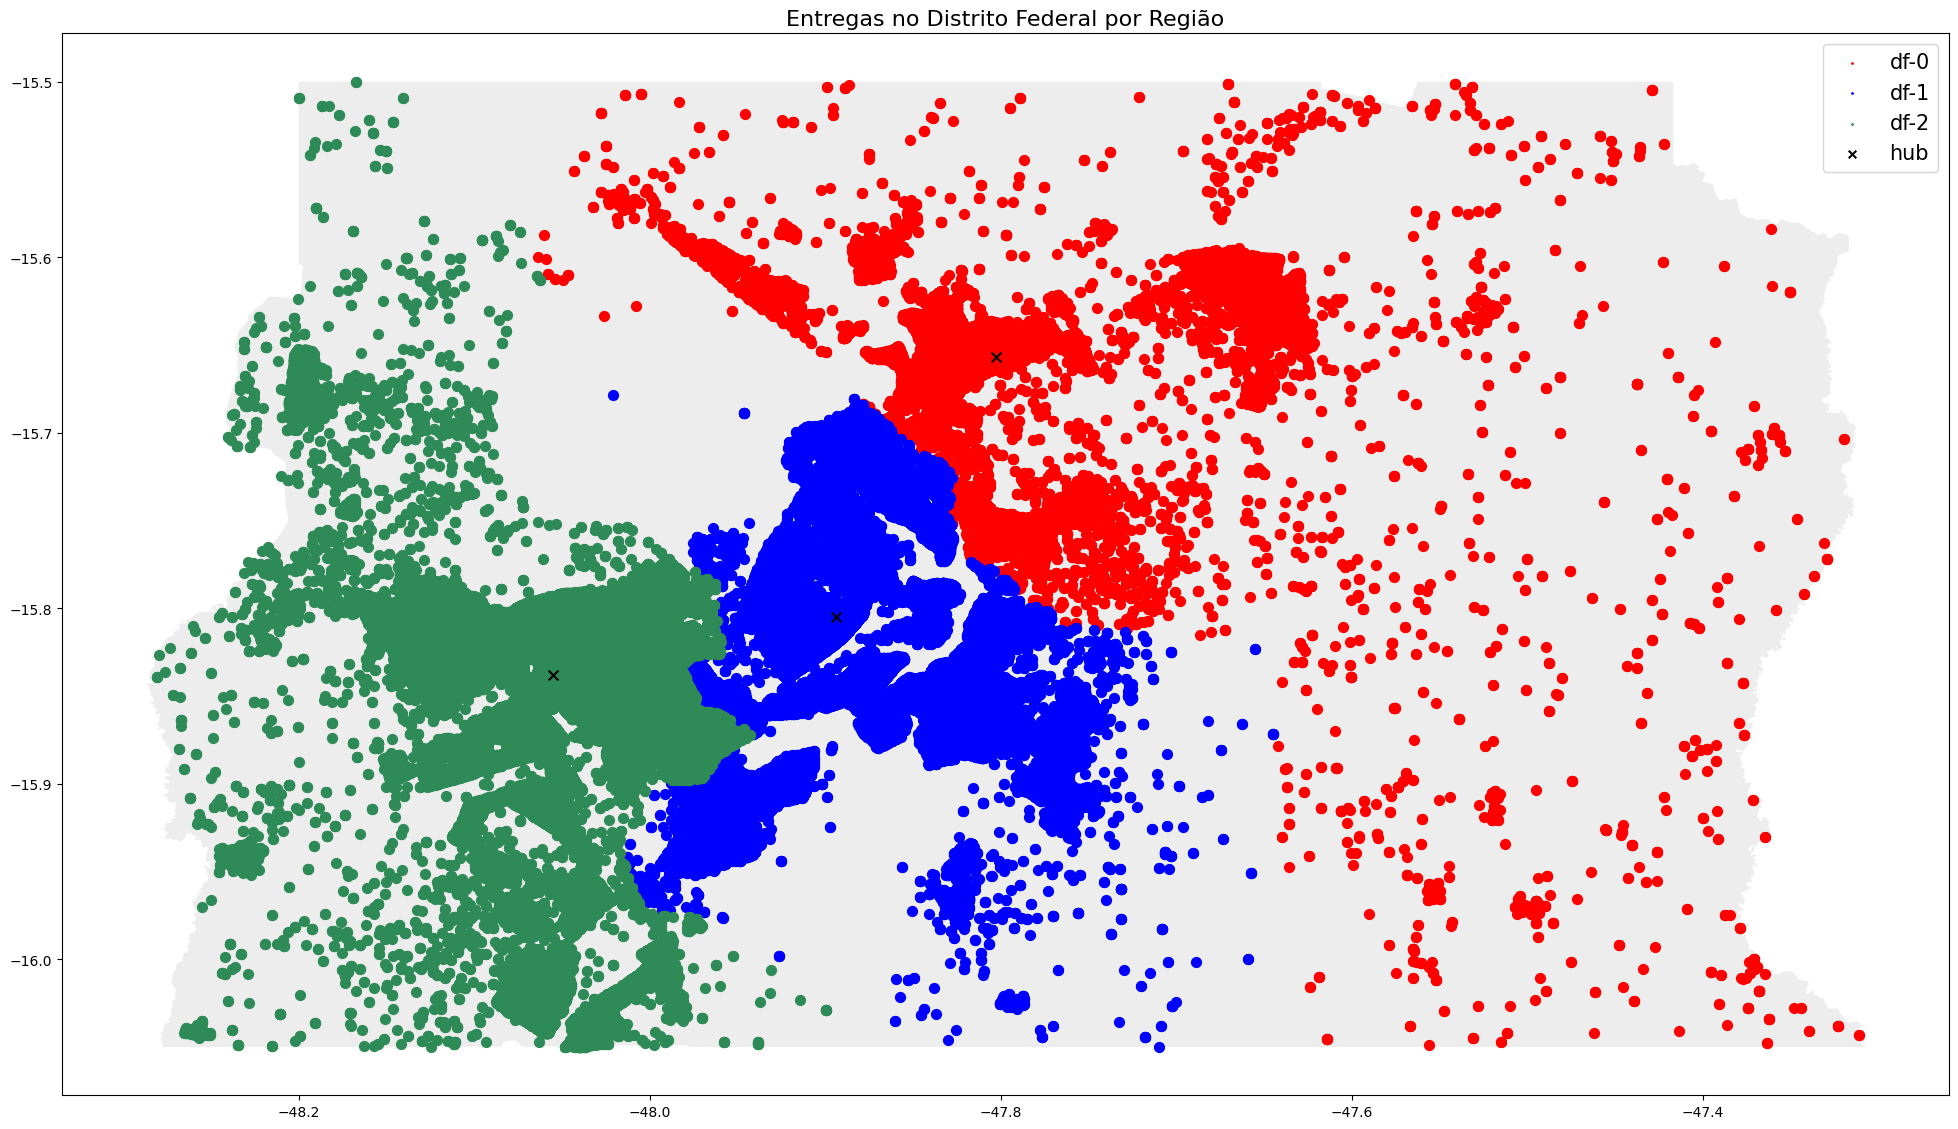

In [63]:
%matplotlib inline

# cria o plot vazio
fig, ax = plt.subplots(figsize=(50/2.54, 50/2.54))  # 50 cm convertido para polegadas

# plot mapa do distrito federal
mapa.plot(ax=ax, alpha=0.4, color="lightgrey")

# plot das entregas
geo_deliveries_df.query("region == 'df-0'").plot(ax=ax, markersize=1, color="red", label="df-0")
geo_deliveries_df.query("region == 'df-1'").plot(ax=ax, markersize=1, color="blue", label="df-1")
geo_deliveries_df.query("region == 'df-2'").plot(ax=ax, markersize=1, color="seagreen", label="df-2")

# plot dos hubs
geo_hub_df.plot(ax=ax, markersize=30, marker="x", color="black", label="hub")

# título
plt.title("Entregas no Distrito Federal por Região", fontdict={"fontsize": 16})

# obter handles e labels antes de criar a legenda
handles, labels = ax.get_legend_handles_labels()
lgnd = ax.legend(handles, labels, prop={"size": 15})

# ajustar tamanho dos marcadores da legenda (se forem scatter markers)
for handle in handles:
    if hasattr(handle, "set_sizes"):
        handle.set_sizes([50])

plt.tight_layout()
plt.show()

In [59]:
data = pd.DataFrame(df_deliveries[['region', 'vehicle_capacity']].value_counts(normalize=True).reset_index())
                    
data.rename(columns={0: 'region_percent'}, inplace=True)

data.head()

,region,vehicle_capacity,proportion
0,df-1,180,0.478988
1,df-2,180,0.410783
2,df-0,180,0.110229


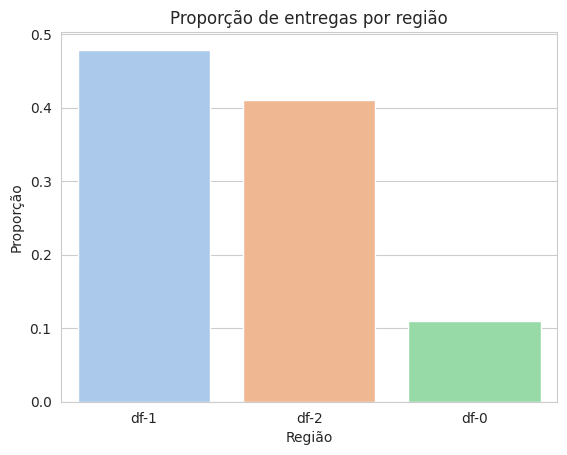

In [60]:
import seaborn as sns


with sns.axes_style('whitegrid'):
    grafico = sns.barplot(
        data=data,
        x='region',
        y='proportion',
        ci=None,
        palette='pastel'
    )
    grafico.set(
        title='Proporção de entregas por região',
        xlabel='Região',
        ylabel='Proporção'
    )